# Обучение модели — Sberbank Russian Housing Market

Загрузка данных и фичей через пайплайн `src/`, разбиение по времени, обучение LightGBM, оценка на валидации, сохранение модели и формирование сабмита.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    RAW_DIR,
    TARGET_COL,
    TIMESTAMP_COL,
    USE_LOG_TARGET,
    TEST_SIZE,
    MODELS_DIR,
    SUBMISSIONS_DIR,
    RANDOM_STATE,
    ensure_dirs,
)
from src.data import load_and_merge, get_test_ids
from src.features import prepare_features
from src.train import get_x_y, time_based_split, train_lgbm, train_xgb, rmse

## 1. Загрузка данных и подготовка признаков

Те же шаги, что в EDA и в `run.py`: объединение с macro, производные признаки, ordinal-кодирование категорий, заполнение пропусков.

In [2]:
ensure_dirs()

feat_kwargs = {
    "add_derived": True,
    "fill_na_numeric": "median",
    "categorical_strategy": "ordinal",
    "drop_high_missing": 0.9,
}

train_df, test_df = load_and_merge(RAW_DIR, with_macro=True)
X_train, y_train, X_test, feature_names = get_x_y(train_df, test_df, **feat_kwargs)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Признаков:", len(feature_names))
print("Целевая: log1p(price_doc)" if USE_LOG_TARGET else "Целевая: price_doc")

X_train: (30471, 394)
X_test: (7662, 394)
Признаков: 394
Целевая: log1p(price_doc)


## 2. Разбиение по времени

Валидация — последние 20% наблюдений по дате сделки (как в тесте — более поздний период).

In [3]:
ts = train_df.loc[X_train.index, TIMESTAMP_COL]
X_tr, X_val, y_tr, y_val = time_based_split(X_train, y_train, ts, test_size=TEST_SIZE)

print("Train (время):", X_tr.shape[0], "объектов")
print("Val:          ", X_val.shape[0], "объектов")
print("Период val:   ", ts.loc[X_val.index].min(), "—", ts.loc[X_val.index].max())

Train (время): 24376 объектов
Val:           6095 объектов
Период val:    2014-11-06 00:00:00 — 2015-06-30 00:00:00


## 3. Обучение LightGBM

Параметры из `src.config.LGBM_PARAMS`; при желании можно переопределить в ячейке.

In [4]:
from src.config import LGBM_PARAMS

# При необходимости переопределить параметры:
# params = {**LGBM_PARAMS, "n_estimators": 300, "learning_rate": 0.03}
params = LGBM_PARAMS.copy()

model_lgbm = train_lgbm(X_tr, y_tr, X_val=X_val, y_val=y_val, params=params)
print("Обучение LightGBM завершено.")

[100]	valid_0's l2: 0.17867
[200]	valid_0's l2: 0.174746
[300]	valid_0's l2: 0.17583
[400]	valid_0's l2: 0.177029
[500]	valid_0's l2: 0.178104
Обучение LightGBM завершено.


## 4. Оценка на валидации

RMSE в лог-пространстве и (для наглядности) в рублях после expm1.

In [5]:
pred_val = model_lgbm.predict(X_val)
val_rmse_log = rmse(y_val.values, pred_val)
val_rmse_rub = rmse(np.expm1(y_val.values), np.expm1(pred_val))

print(f"RMSE (log): {val_rmse_log:.4f}")
print(f"RMSE (руб): {val_rmse_rub:,.0f}")

RMSE (log): 0.4220
RMSE (руб): 3,170,138


## 5. Важность признаков

Топ-30 признаков по важности (gain/feature_importances_).

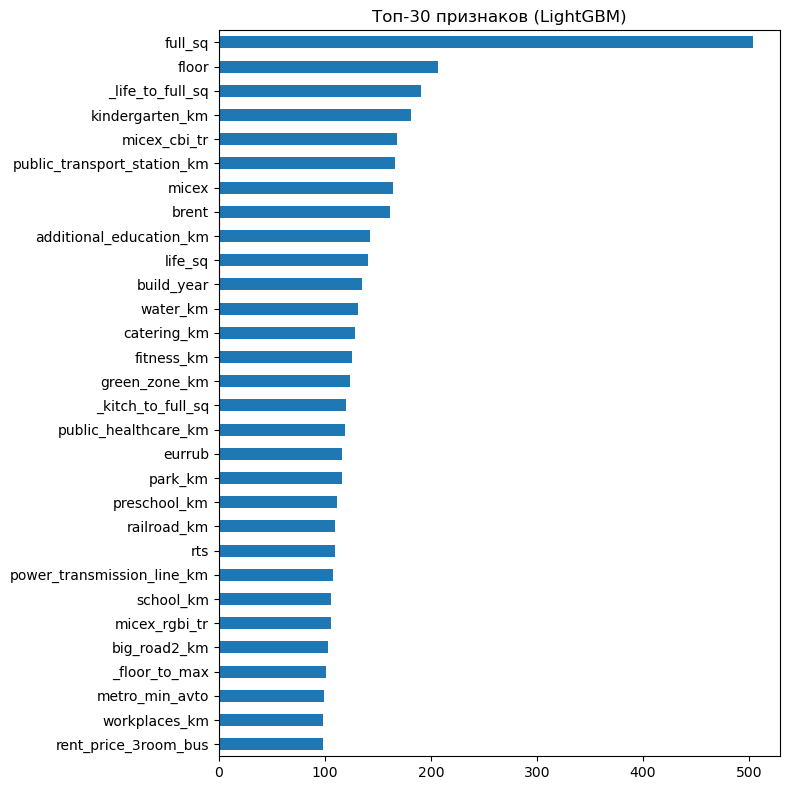

In [6]:
imp = pd.Series(model_lgbm.feature_importances_, index=feature_names).sort_values(ascending=False)
imp.head(30).plot(kind="barh", figsize=(8, 8), title="Топ-30 признаков (LightGBM)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Сохранение модели

Модель и список признаков сохраняются в `models/` (формат как у `run.py train`).

In [7]:
import joblib

MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODELS_DIR / "model.joblib"
joblib.dump({"model": model_lgbm, "feature_names": feature_names}, model_path)
print(f"Модель сохранена: {model_path}")

Модель сохранена: /Users/macpro/Documents/GitHub/repositories/kaggle_rep/sberbank_housing/models/model.joblib


## 7. Предсказание на test и сабмит

Предсказываем по тестовой выборке, переводим из лога в рубли, сохраняем CSV для Kaggle.

In [8]:
from src.predict import predict

pred_test = predict(model_lgbm, X_test, feature_names)
if USE_LOG_TARGET:
    pred_test = np.expm1(pred_test)

ids = get_test_ids(test_df)
submission = pd.DataFrame({"id": ids, TARGET_COL: pred_test})

SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)
sub_path = SUBMISSIONS_DIR / "submission.csv"
submission.to_csv(sub_path, index=False)

print(f"Сабмит сохранён: {sub_path}")
print(f"Строк: {len(submission)}")
submission.head(10)

Сабмит сохранён: /Users/macpro/Documents/GitHub/repositories/kaggle_rep/sberbank_housing/submissions/submission.csv
Строк: 7662


,id,price_doc
0,30474,5.757435e+06
1,30475,7.724968e+06
2,30476,5.110774e+06
3,30477,5.778302e+06
4,30478,4.772046e+06
5,30479,6.561480e+06
6,30480,4.120122e+06
7,30481,4.465906e+06
8,30482,4.700593e+06
9,30483,4.681694e+06
